# $C_\ell$ vs Theory: Cardinal Gold & Flagship Gold Mocks

Compares measured galaxy clustering power spectra $C_\ell^{gg}$ to theory
predictions using the fiducial cosmological parameters of each simulation
and a linear bias fitted per redshift bin from the auto-spectra.

**Runs compared:**
- **Cardinal Gold** (`cardinal_gold_snri5`): $\Omega_m=0.286$, $\Omega_b=0.047$, $\sigma_8=0.82$, $n_s=0.96$, $h=0.7$
- **Flagship Gold** (`flagship_gold_snri5`): $\Omega_m=0.319$, $\Omega_b=0.049$, $\sigma_8=0.813$, $n_s=0.96$, $h=0.67$

Both runs use a maglim $r<23.5$ + $i$-band SNR $>5$ selection with 3 tomographic bins
($0.4 < z < 1.0$) and NaMaster mode deprojection of 24 survey systematics maps.

Each panel shows scaled $C_\ell$ with error bars and the theory line (top),
and normalised residuals $(C_\ell^{\rm data} - C_\ell^{\rm theory}) / \sigma$ (bottom).

**How this notebook is organized:**
1. **Setup** — imports, utility functions, and run configuration used throughout.
2. **Cardinal** — all single-sim measurements, fits, and diagnostics for Cardinal Gold.
3. **Flagship** — the same set of measurements, fits, and diagnostics for Flagship Gold.
4. **Comparisons** — every plot that overlays Cardinal and Flagship directly.

## Setup

Defines everything reused below: sacc/mask/catalog loaders, the theory-$C_\ell$ calculation (fiducial cosmology + per-bin linear bias fit + HEALPix pixel window), plotting helpers, and the run configuration (file paths and fiducial cosmological parameters for each simulation). Nothing in this section is sim-specific — it is only function and constant definitions.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sacc
import pyccl as ccl
import h5py
from scipy.interpolate import interp1d
import healpy as hp

In [6]:
# ── Utility functions ──────────────────────────────────────────────────────────

def load_cls(sacc_file):
    """Load galaxy_density_cl measurements with bandpower windows and covariance.

    Returns
    -------
    s    : sacc.Sacc
    data : {(t1, t2): {'ell', 'cl', 'err', 'cov', 'l_bpw', 'w_bpw'}}
    """
    s = sacc.Sacc.load_fits(sacc_file)
    pairs = s.get_tracer_combinations('galaxy_density_cl')
    data = {}
    for t1, t2 in pairs:
        ell, cl, cov, ind = s.get_ell_cl(
            'galaxy_density_cl', t1, t2, return_cov=True, return_ind=True
        )
        bpw = s.get_bandpower_windows(ind)
        data[(t1, t2)] = {
            'ell':   ell,
            'cl':    cl,
            'err':   np.sqrt(np.diag(cov)),
            'cov':   cov,
            'l_bpw': bpw.values,
            'w_bpw': bpw.weight.T,
        }
    return s, data


def parse_bin_index(tracer_name):
    """'lens_2' -> 2"""
    try:
        return int(tracer_name.rsplit('_', 1)[-1])
    except ValueError:
        return 0


def bin_label(tracer_name):
    """'lens_0' -> 'Lens 0'"""
    parts = tracer_name.rsplit('_', 1)
    return f'{parts[0].capitalize()} {parts[1]}' if len(parts) == 2 else tracer_name


def eval_interp_cl(cl_in, l_sample, l_bpw, w_bpw):
    """Interpolate C_ell in log-ell space and convolve with bandpower window.
    Matches Cosmotheka's Limber._eval_interp_cl exactly.
    """
    f = interp1d(np.log(1e-3 + l_sample), cl_in,
                 bounds_error=False, fill_value='extrapolate')
    return np.dot(w_bpw, f(np.log(1e-3 + l_bpw)))


def fit_bias_analytic(l, cl_data, cl_mm, err, ell_min=30, ell_max=300):
    """Least-squares linear bias from an auto-spectrum.

    Model: cl_data = b^2 * cl_mm  =>  b^2 = sum(d*m/sigma^2) / sum(m^2/sigma^2)
    Fit is restricted to bandpower bins with ell_min <= l <= ell_max.
    Returns b = sqrt(b^2), floored at 0.
    """
    mask = (l >= ell_min) & (l <= ell_max)
    if mask.sum() == 0:
        raise ValueError(f'No ell bins in [{ell_min}, {ell_max}]. Available: {l}')
    b2 = (np.sum(cl_data[mask] * cl_mm[mask] / err[mask]**2) /
          np.sum(cl_mm[mask]**2 / err[mask]**2))
    return float(np.sqrt(max(b2, 0.0)))


def get_shot_noise(metadata_path, tracer_names):
    """1/n_bar shot noise per tracer from TXPipe tracer_metadata.hdf5."""
    with h5py.File(metadata_path, 'r') as f:
        counts  = f['tracers/lens_counts'][:]
        density = f['tracers/lens_density'][:]  # gal / arcmin^2
    arcmin2_per_sr = (180.0 * 60.0 / np.pi) ** 2
    area_sr = counts / (density * arcmin2_per_sr)
    return {name: float(1.0 / (counts[i] / area_sr[i]))
            for i, name in enumerate(tracer_names)}


def compute_theory_cls(s, cosmo_params, cls_data, ell_min_bias=30, ell_max_bias=300,
                       nside=512):
    """Theory Cls from fiducial cosmology with per-bin linear bias fitted to data,
    including the HEALPix pixel window function W_ell^2 at the given nside.

    Parameters
    ----------
    s           : sacc.Sacc  (used for n(z) tracers)
    cosmo_params: dict with keys Omega_m, Omega_b, sigma8, n_s, h
    cls_data    : output of load_cls

    Returns
    -------
    theory : {(t1, t2): {'ell', 'cl_theory', 'cl_b1'}}
    bias   : {tracer_name: fitted_bias_value}
    """
    cosmo = ccl.Cosmology(
        Omega_c=cosmo_params['Omega_m'] - cosmo_params['Omega_b'],
        Omega_b=cosmo_params['Omega_b'],
        h=cosmo_params['h'],
        n_s=cosmo_params['n_s'],
        sigma8=cosmo_params['sigma8'],
        matter_power_spectrum='halofit',
    )

    # ell sampling: 30 log-spaced points per decade over the bandpower window range
    all_l_bpw = np.concatenate([d['l_bpw'] for d in cls_data.values()])
    l_min = max(float(all_l_bpw.min()), 2.0)
    l_max = float(all_l_bpw.max())
    nl = int(np.log10(l_max / l_min) * 30)
    l_sample = np.unique(np.geomspace(l_min, l_max + 1, nl).astype(int)).astype(float)

    # CCL tracers with bias=1 to allow analytic bias scaling
    tracer_names = sorted({t for pair in cls_data for t in pair}, key=parse_bin_index)
    ccl_tracers = {}
    for name in tracer_names:
        t = s.tracers[name]
        ccl_tracers[name] = ccl.NumberCountsTracer(
            cosmo, dndz=(t.z, t.nz),
            bias=(t.z, np.ones_like(t.z)),
            has_rsd=False,
        )

    # Pixel window function W_ell^2 for HEALPix maps at `nside`
    _wl  = hp.pixwin(nside, lmax=int(l_max) + 10)
    _W_sq = _wl[l_sample.astype(int)] ** 2

    # Compute Cls with b=1, apply pixel window, convolve with bandpower windows
    cl_b1 = {}
    for t1, t2 in cls_data:
        cl_raw = ccl.angular_cl(cosmo, ccl_tracers[t1], ccl_tracers[t2], l_sample)
        d = cls_data[(t1, t2)]
        cl_b1[(t1, t2)] = eval_interp_cl(cl_raw * _W_sq, l_sample, d['l_bpw'], d['w_bpw'])

    # Fit linear bias per bin using auto-spectra
    bias = {}
    for name in tracer_names:
        d = cls_data[(name, name)]
        bias[name] = fit_bias_analytic(
            d['ell'], d['cl'], cl_b1[(name, name)], d['err'],
            ell_min=ell_min_bias, ell_max=ell_max_bias,
        )

    theory = {
        (t1, t2): {
            'ell':       cls_data[(t1, t2)]['ell'],
            'cl_theory': bias[t1] * bias[t2] * cl_b1[(t1, t2)],
            'cl_b1':     cl_b1[(t1, t2)],
        }
        for t1, t2 in cls_data
    }
    return theory, bias


def plot_cls_vs_theory(cls_data, theory_results, title,
                       shot_noise=None, scale='linear', fname=None):
    """Lower-triangular grid comparing measured Cls to theory.

    Each panel: scaled C_ell with error bars + theory line (top panel),
    normalised residuals (data - theory) / sigma (bottom panel).

    Parameters
    ----------
    scale : 'linear'  -> ell^1.3 factor, linear axes
            'loglog'  -> ell*(ell+1)/2pi factor, log-log axes
    """
    tracer_names = sorted({t for pair in cls_data for t in pair}, key=parse_bin_index)
    n_bins = len(tracer_names)
    tidx   = {t: i for i, t in enumerate(tracer_names)}
    pairs_sorted = sorted(
        cls_data.keys(),
        key=lambda p: (parse_bin_index(p[0]), parse_bin_index(p[1])),
    )

    height_ratios = [3, 1, 0.3] * n_bins
    fig, axes = plt.subplots(
        n_bins * 3, n_bins,
        figsize=(4.5 * n_bins, 4.5 * n_bins),
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05, 'wspace': 0.35},
    )
    DATA_COLOR = '#AE7182'

    for dr in range(n_bins):
        for c in range(n_bins):
            if c > dr:
                for r in range(3):
                    axes[dr * 3 + r, c].axis('off')

    for i_pair, (t1, t2) in enumerate(pairs_sorted):
        dr  = max(tidx[t1], tidx[t2])
        col = min(tidx[t1], tidx[t2])
        ax_cl  = axes[dr * 3,     col]
        ax_res = axes[dr * 3 + 1, col]
        axes[dr * 3 + 2, col].axis('off')

        d     = cls_data[(t1, t2)]
        th    = theory_results[(t1, t2)]
        ell   = d['ell']
        cl    = d['cl']
        err   = d['err']
        cl_th = th['cl_theory']

        if scale == 'loglog':
            fac    = ell * (ell + 1) / (2 * np.pi)
            ylabel = r'$\ell(\ell+1)C_\ell / 2\pi$'
        else:
            fac    = ell ** 1.3
            ylabel = r'$\ell^{1.3}\,C_\ell$'

        # C_ell panel
        ax_cl.errorbar(ell, fac * cl, yerr=fac * err,
                       fmt='o', ms=4, capsize=3, color=DATA_COLOR, label='Data')
        ax_cl.plot(ell, fac * cl_th, '-', lw=1.8, color='k',
                   label='Theory (fitted bias)')
        if shot_noise is not None and t1 == t2:
            ax_cl.plot(ell, fac * shot_noise[t1],
                       color='grey', lw=1.2, ls=':', label='Shot noise')
        if scale == 'loglog':
            ax_cl.set_xscale('log')
            ax_cl.set_yscale('log')

        lbl = (f'{bin_label(t1)} x {bin_label(t2)}' if t1 != t2
               else f'{bin_label(t1)} (auto)')
        ax_cl.set_title(lbl, fontsize=9)
        ax_cl.tick_params(labelbottom=False)
        ax_cl.set_xlim(ell.min() * 0.8, ell.max() * 1.2)
        if col == 0:
            ax_cl.set_ylabel(ylabel, fontsize=8)
        if dr == 0 and col == 0:
            ax_cl.legend(fontsize=7)

        # Residual panel
        res = (cl - cl_th) / err
        ax_res.axhline(0, color='k', lw=1, ls='--')
        ax_res.fill_between(
            [ell.min() * 0.8, ell.max() * 1.2], -1, 1, color='grey', alpha=0.2
        )
        ax_res.errorbar(ell, res, yerr=np.ones_like(ell),
                        fmt='o', ms=3, capsize=2, color=DATA_COLOR)
        if scale == 'loglog':
            ax_res.set_xscale('log')
        ax_res.set_ylim(-5, 5)
        ax_res.set_xlim(ell.min() * 0.8, ell.max() * 1.2)
        ax_res.tick_params(labelsize=7)
        if col == 0:
            ax_res.set_ylabel(r'$\Delta/\sigma$', fontsize=7)
        if dr == n_bins - 1:
            ax_res.set_xlabel(r'$\ell$', fontsize=8)
        else:
            ax_res.tick_params(labelbottom=False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    return fig


def plot_cls_overlay(cls_a, cls_b, label_a, label_b, title,
                     scale='linear', fname=None):
    """Lower-triangular grid overlaying measured Cls from two runs.

    Parameters
    ----------
    cls_a, cls_b : dicts from load_cls
    scale : 'linear'  -> ell^1.3 factor, linear axes
            'loglog'  -> ell*(ell+1)/2pi factor, log-log axes
    """
    tracer_names = sorted({t for pair in cls_a for t in pair}, key=parse_bin_index)
    n_bins = len(tracer_names)
    tidx   = {t: i for i, t in enumerate(tracer_names)}
    pairs_sorted = sorted(
        cls_a.keys(),
        key=lambda p: (parse_bin_index(p[0]), parse_bin_index(p[1])),
    )

    fig, axes = plt.subplots(
        n_bins, n_bins,
        figsize=(4.5 * n_bins, 4.0 * n_bins),
        squeeze=False,
    )
    fig.suptitle(title, fontsize=13, y=1.01)

    for r in range(n_bins):
        for c in range(n_bins):
            if c > r:
                axes[r][c].set_visible(False)

    for i_pair, (t1, t2) in enumerate(pairs_sorted):
        row = max(tidx[t1], tidx[t2])
        col = min(tidx[t1], tidx[t2])
        ax  = axes[row][col]

        d_a = cls_a[(t1, t2)]
        d_b = cls_b[(t1, t2)]
        ell_a, cl_a, err_a = d_a['ell'], d_a['cl'], d_a['err']
        ell_b, cl_b, err_b = d_b['ell'], d_b['cl'], d_b['err']

        if scale == 'loglog':
            fac_a  = ell_a * (ell_a + 1) / (2 * np.pi)
            fac_b  = ell_b * (ell_b + 1) / (2 * np.pi)
            ylabel = r'$\ell(\ell+1)C_\ell / 2\pi$'
        else:
            fac_a  = ell_a ** 1.3
            fac_b  = ell_b ** 1.3
            ylabel = r'$\ell^{1.3}\,C_\ell$'

        ax.errorbar(ell_a, fac_a * cl_a, yerr=fac_a * err_a,
                    fmt='o', ms=4, lw=1.5, capsize=3, capthick=1.2,
                    color=CARDINAL_COLOR, label=label_a)
        ax.errorbar(ell_b * 1.04, fac_b * cl_b, yerr=fac_b * err_b,
                    fmt='s', ms=4, lw=1.5, capsize=3, capthick=1.2,
                    color=FLAGSHIP_COLOR, linestyle='--', label=label_b)

        if scale == 'loglog':
            ax.set_xscale('log')
            ax.set_yscale('log')

        ax.grid(True, which='both', ls=':', alpha=0.35)
        lbl = (f'{bin_label(t1)} x {bin_label(t2)}' if t1 != t2
               else f'{bin_label(t1)} (auto)')
        ax.set_title(lbl, fontsize=9,
                     fontweight='bold' if t1 == t2 else 'normal')
        ax.set_xlabel(r'$\ell$', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=8)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, framealpha=0.8)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    return fig

def read_txpipe_mask(mask_path):
    """Read a sparse TXPipe HEALPix mask from HDF5, return (full_map, nside, attrs)."""
    with h5py.File(mask_path) as f:
        grp   = f['maps/mask']
        pixel = grp['pixel'][:]
        value = grp['value'][:]
        attrs = dict(grp.attrs)
        nside = int(attrs['nside'])
    full = np.full(hp.nside2npix(nside), hp.UNSEEN)
    full[pixel] = value
    return full, nside, attrs

In [7]:
# ── Catalog / magnitude readers ──────────────────────────────────────────────────
import time

_BASE = 'data/outputs'
PHOT_PATHS = {
    'Cardinal': f'{_BASE}/cardinal_gold_snri5/photometry_catalog.hdf5',
    'Flagship': f'{_BASE}/flagship_gold_snri5/photometry_catalog.hdf5',
}
TOMO_PATHS = {
    'Cardinal': f'{_BASE}/cardinal_gold_snri5/lens_tomography_catalog.hdf5',
    'Flagship': f'{_BASE}/flagship_gold_snri5/lens_tomography_catalog.hdf5',
}
MAP_PATHS = {
    'Cardinal': f'{_BASE}/cardinal_gold_snri5/density_maps.hdf5',
    'Flagship': f'{_BASE}/flagship_gold_snri5/density_maps.hdf5',
}
BANDS = ['u', 'g', 'r', 'i', 'z', 'y']


def read_nz_from_catalogs(run_label, n_z_bins=80):
    """Weighted true-redshift histogram per lens bin from TXPipe output catalogs.

    Returns
    -------
    z_mid    : midpoints of histogram bins
    nz       : {bin_index: normalised histogram array}
    counts   : {bin_index: number of selected galaxies}
    zedges   : tomographic bin edges from the catalog attrs
    """
    t0 = time.time()
    print(f'[{run_label}] reading tomography ...', end=' ', flush=True)
    with h5py.File(TOMO_PATHS[run_label]) as f:
        tomo_bin    = f['tomography/bin'][:]
        lens_weight = f['tomography/lens_weight'][:]
        nbin        = int(f['tomography'].attrs['nbin'])
        zedges      = np.array(f['tomography'].attrs['zbin_edges'])
    print(f'{time.time()-t0:.1f}s')

    t0 = time.time()
    print(f'[{run_label}] reading redshift_true (~3 GB) ...', end=' ', flush=True)
    with h5py.File(PHOT_PATHS[run_label]) as f:
        z_true = f['photometry/redshift_true'][:]
    print(f'{time.time()-t0:.1f}s')

    n_total = len(z_true)
    n_lens  = int((tomo_bin >= 0).sum())
    print(f'[{run_label}] total={n_total:,}  lens-selected={n_lens:,}  ({100*n_lens/n_total:.1f}%)')
    for b in range(nbin):
        print(f'  bin {b} ({zedges[b]:.1f}-{zedges[b+1]:.1f}): {(tomo_bin==b).sum():,}')

    z_lo = max(0.0, float(zedges[0]) - 0.15)
    z_hi = float(zedges[-1]) + 0.25
    z_edges = np.linspace(z_lo, z_hi, n_z_bins + 1)
    z_mid   = 0.5 * (z_edges[:-1] + z_edges[1:])

    nz, counts = {}, {}
    for b in range(nbin):
        sel = tomo_bin == b
        h, _ = np.histogram(z_true[sel], bins=z_edges, weights=lens_weight[sel])
        norm = np.trapz(h, z_mid)
        nz[b]     = h / norm if norm > 0 else h
        counts[b] = int(sel.sum())

    return z_mid, nz, counts, zedges


def read_density_map(run_label, bin_idx):
    """Reconstruct full HEALPix overdensity map from sparse TXPipe density_maps.hdf5."""
    with h5py.File(MAP_PATHS[run_label]) as f:
        grp   = f[f'maps/delta_{bin_idx}']
        pixel = grp['pixel'][:]
        value = grp['value'][:]
        nside = int(grp.attrs['nside'])
    full = np.full(hp.nside2npix(nside), hp.UNSEEN)
    full[pixel] = value
    return full, nside


def read_magnitudes(run_label):
    """Read magnitudes for all lens-selected galaxies from TXPipe output.

    Returns
    -------
    mags     : {band: 1-D array for lens-selected galaxies}
    bin_mask : {bin_index: boolean mask within lens-selected}
    weights  : lens_weight for lens-selected galaxies
    zedges   : tomographic bin edges
    """
    t0 = time.time()
    print(f'[{run_label}] reading tomography ...', end=' ', flush=True)
    with h5py.File(TOMO_PATHS[run_label]) as f:
        tomo_bin    = f['tomography/bin'][:]
        lens_weight = f['tomography/lens_weight'][:]
        nbin        = int(f['tomography'].attrs['nbin'])
        zedges      = np.array(f['tomography'].attrs['zbin_edges'])
    print(f'{time.time()-t0:.1f}s')

    sel            = tomo_bin >= 0
    bins_selected  = tomo_bin[sel]
    weights        = lens_weight[sel]
    print(f'[{run_label}] lens-selected: {sel.sum():,}')

    mags = {}
    with h5py.File(PHOT_PATHS[run_label]) as f:
        for band in BANDS:
            t0 = time.time()
            print(f'  mag_{band} ...', end=' ', flush=True)
            full = f[f'photometry/mag_{band}'][:]
            mags[band] = full[sel]
            del full
            print(f'{time.time()-t0:.1f}s')

    bin_mask = {b: bins_selected == b for b in range(nbin)}
    return mags, bin_mask, weights, zedges

In [8]:
# ── Configuration ──────────────────────────────────────────────────────────────
BASE = 'data/outputs'

runs = {
    'Cardinal': {
        'label': 'Cardinal Gold (SNR>5)',
        'mask': '/pscratch/sd/a/anicola/DP2/data/masks/cardinal_mask_m5ext_final_nside512.hdf5',
        'sacc': f'{BASE}/cardinal_gold_snri5/summary_statistics_fourier.sacc',
        'meta': f'{BASE}/cardinal_gold_snri5/tracer_metadata.hdf5',
        'cosmo': {
            'Omega_m': 0.286, 'Omega_b': 0.047, 'sigma8': 0.82,
            'n_s': 0.96, 'h': 0.7,
        },
    },
    'Flagship': {
        'label': 'Flagship Gold (SNR>5)',
        'mask': '/pscratch/sd/a/anicola/DP2/data/masks/flagship_gold_snri5_mask_m5ext_final_nside512.hdf5',
        'sacc': f'{BASE}/flagship_gold_snri5/summary_statistics_fourier.sacc',
        'meta': f'{BASE}/flagship_gold_snri5/tracer_metadata.hdf5',
        'cosmo': {
            'Omega_m': 0.319, 'Omega_b': 0.049, 'sigma8': 0.813,
            'n_s': 0.96, 'h': 0.67,
        },
    },
}

BIAS_ELL_MIN = 30
BIAS_ELL_MAX = 300
SCALE        = 'linear'   # 'linear' or 'loglog'
NSIDE_MAP    = 512        # HEALPix nside of the TXPipe density maps

# Colors for Cardinal-vs-Flagship comparison plots (validated CVD-safe pair)
CARDINAL_COLOR = '#4a3aa7'   # violet
FLAGSHIP_COLOR = '#e87ba4'   # magenta

## Cardinal

All measurements, theory fits, and diagnostics in this section use the **Cardinal Gold** run only. Two-sim comparison plots are collected in the Comparisons section at the end of the notebook.

### $C_\ell$ vs theory

Loads the measured `galaxy_density_cl` bandpowers and covariance from the sacc file, computes the fiducial-cosmology theory prediction ($\Lambda$CDM + linear bias), and fits a single linear bias per redshift bin by least squares on the auto-spectra (restricted to $30 \le \ell \le 300$). Prints $\chi^2$/dof per tracer pair, then plots measured $C_\ell$ against theory with normalised residuals.

In [9]:
cfg = runs['Cardinal']

# Load data
s_c, cls_c = load_cls(cfg['sacc'])
tracer_names_c = sorted(s_c.tracers.keys(), key=parse_bin_index)
print(f'Tracers : {tracer_names_c}')
print(f'Pairs   : {list(cls_c.keys())}')

# Shot noise
shot_c = get_shot_noise(cfg['meta'], tracer_names_c)
print('\nShot noise N_ell (already subtracted from data):')
for name, N in shot_c.items():
    print(f'  {name}: {N:.3e}')

# Theory prediction
theory_c, bias_c = compute_theory_cls(
    s_c, cfg['cosmo'], cls_c,
    ell_min_bias=BIAS_ELL_MIN, ell_max_bias=BIAS_ELL_MAX,
    nside=NSIDE_MAP,
)
print(f'\nFitted linear bias (ell in [{BIAS_ELL_MIN}, {BIAS_ELL_MAX}]):')
for name, b in sorted(bias_c.items(), key=lambda x: parse_bin_index(x[0])):
    print(f'  {name}: b = {b:.4f}')

# Chi-squared per pair
print('\nchi2/N per pair:')
print(f'  {"Pair":24s}  {"chi2/N":>7}  N')
for (t1, t2), d in cls_c.items():
    cl_th = theory_c[(t1, t2)]['cl_theory']
    chi2  = np.sum(((d['cl'] - cl_th) / d['err'])**2)
    n     = len(d['cl'])
    print(f'  {t1} x {t2:8s}  {chi2/n:7.2f}  {n}')

Tracers : ['lens_0', 'lens_1', 'lens_2']
Pairs   : [('lens_0', 'lens_0'), ('lens_1', 'lens_0'), ('lens_1', 'lens_1'), ('lens_2', 'lens_0'), ('lens_2', 'lens_1'), ('lens_2', 'lens_2')]

Shot noise N_ell (already subtracted from data):
  lens_0: 3.152e-08
  lens_1: 4.455e-08
  lens_2: 9.708e-08

Fitted linear bias (ell in [30, 300]):
  lens_0: b = 1.2569
  lens_1: b = 1.3076
  lens_2: b = 1.2790

chi2/N per pair:
  Pair                       chi2/N  N
  lens_0 x lens_0     252.29  19
  lens_1 x lens_0       9.22  19
  lens_1 x lens_1     157.55  19
  lens_2 x lens_0      29.19  19
  lens_2 x lens_1      19.04  19
  lens_2 x lens_2       5.46  19


/tmp/ipykernel_2016790/2712830020.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


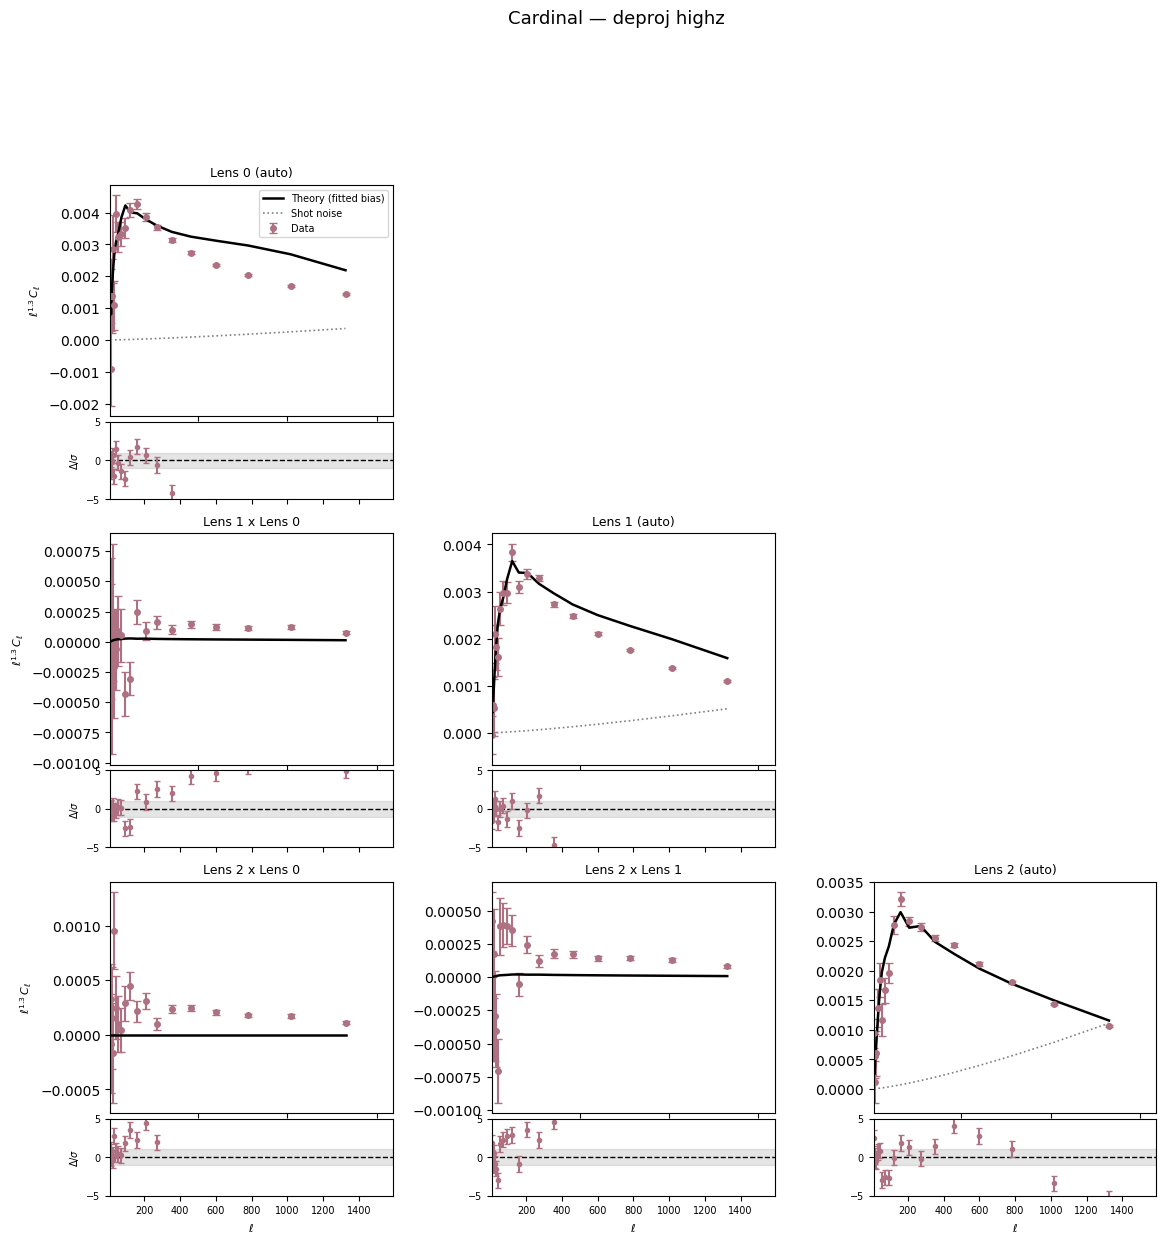

In [10]:
fig_c = plot_cls_vs_theory(
    cls_c, theory_c,
    title='Cardinal — deproj highz',
    shot_noise=shot_c,
    scale=SCALE,
)
plt.show()

### n(z) and density maps from catalogs

As a cross-check on the sacc n(z), reads `redshift_true` directly from the TXPipe photometry catalog and re-derives the weighted true-redshift distribution per tomographic bin from the lens tomography catalog. Also reconstructs the sparse HEALPix overdensity maps (`density_maps.hdf5`) that fed the $C_\ell$ measurement above. The `redshift_true` read is ~3 GB and takes ~1-2 minutes.

In [11]:
# Reads ~3 GB — takes ~1-2 min
nz_catalog = {}
_z_mid, _nz, _counts, _zedges = read_nz_from_catalogs('Cardinal')
nz_catalog['Cardinal'] = {
    'z_mid': _z_mid, 'nz': _nz, 'counts': _counts, 'zedges': _zedges,
}

[Cardinal] reading tomography ... 4.9s
[Cardinal] reading redshift_true (~3 GB) ... 4.4s
[Cardinal] total=392,718,269  lens-selected=34,958,287  (8.9%)
  bin 0 (0.4-0.6): 17,201,303
  bin 1 (0.6-0.8): 12,171,966
  bin 2 (0.8-1.0): 5,585,018


/tmp/ipykernel_2016790/2784462028.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(h, z_mid)


/pscratch/sd/a/anicola/DP2/code/TXPipe/conda/lib/python3.13/site-packages/healpy/visufunc.py:1504: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


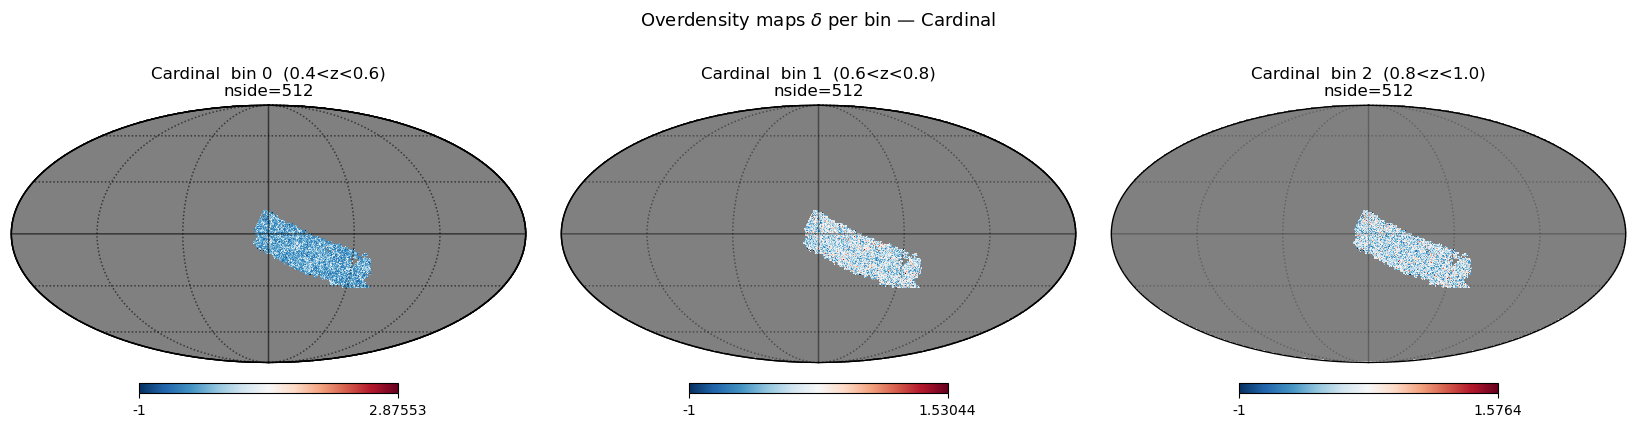

In [12]:
_nbin = 3
_label = 'Cardinal'
_zedges = nz_catalog[_label]['zedges']

fig_maps_cardinal = plt.figure(figsize=(5.5 * _nbin, 4.0))

for _b in range(_nbin):
    _dmap, _nside = read_density_map(_label, _b)
    _zlo = float(_zedges[_b])
    _zhi = float(_zedges[_b + 1])
    _sub = (1, _nbin, _b + 1)

    # clip colour range to +/-3 sigma for better contrast
    _vals = _dmap[_dmap != hp.UNSEEN]
    _vmax = float(np.percentile(np.abs(_vals), 99))

    hp.mollview(
        _dmap,
        fig=fig_maps_cardinal.number,
        sub=_sub,
        title=f'{_label}  bin {_b}  ({_zlo:.1f}<z<{_zhi:.1f})\nnside={_nside}',
        cmap='RdBu_r',
        cbar=True,
        notext=True,
        margins=(0.01, 0.02, 0.01, 0.02),
    )
    hp.graticule(dpar=30, dmer=60, alpha=0.25, verbose=False)

fig_maps_cardinal.suptitle(r'Overdensity maps $\delta$ per bin — Cardinal', fontsize=13, y=1.05)
plt.show()

### Magnitudes

Reads *ugrizy* magnitudes for all lens-selected galaxies directly from the photometry catalog. This data is reused later for the magnitude-distribution and color-color comparison plots. Reading 6 magnitude columns (~3 GB each for Cardinal) takes ~3-5 minutes.

In [13]:
# Read magnitudes (~3-5 min)
mag_data = {}
_mags, _bin_mask, _weights, _zedges = read_magnitudes('Cardinal')
mag_data['Cardinal'] = {
    'mags': _mags, 'bin_mask': _bin_mask,
    'weights': _weights, 'zedges': _zedges,
}

[Cardinal] reading tomography ... 1.9s
[Cardinal] lens-selected: 34,958,287
  mag_u ... 6.3s
  mag_g ... 6.0s
  mag_r ... 5.5s
  mag_i ... 6.6s
  mag_z ... 5.3s
  mag_y ... 7.1s


### Mask and footprint statistics

Plots the survey mask and cross-checks footprint statistics (area, $f_{\rm sky}$, per-bin galaxy counts and density) from `tracer_metadata.hdf5` against the mask file and a from-scratch recomputation.

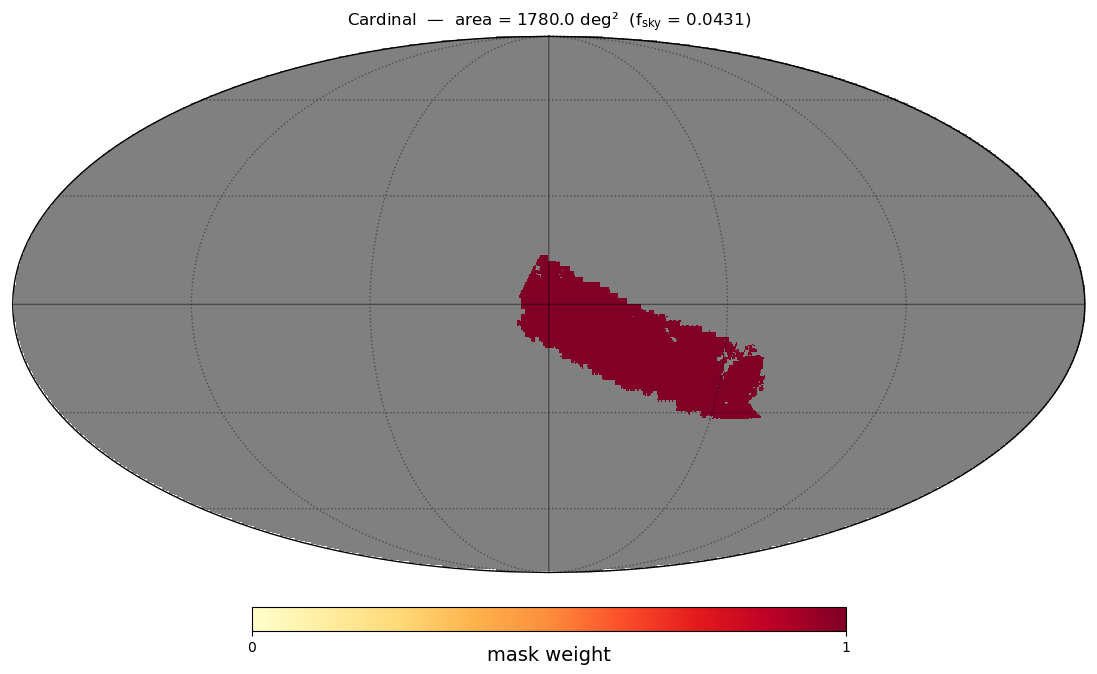

In [14]:
_mask_map, _nside, _attrs = read_txpipe_mask(runs['Cardinal']['mask'])
_area  = float(_attrs.get('area',  _attrs.get('area_deg2',  0)))
_fsky  = float(_attrs.get('f_sky', _attrs.get('f_sky_computed', 0)))
_title = (f"Cardinal  —  area = {_area:.1f} deg²  "
          f"(f$_{{\\rm sky}}$ = {_fsky:.4f})")

fig_mask_cardinal = plt.figure(figsize=(12, 6.5))
hp.mollview(
    _mask_map,
    fig=fig_mask_cardinal.number,
    sub=(1, 1, 1),
    title=_title,
    cmap='YlOrRd',
    min=0, max=1,
    cbar=True,
    notext=False,
    unit='mask weight',
)
hp.graticule(dpar=30, dmer=60, alpha=0.4, verbose=False)
plt.show()

In [15]:
_label = 'Cardinal'
print(f"{'='*60}")
print(f"  {_label}  —  footprint statistics from tracer_metadata.hdf5")
print(f"{'='*60}")

with h5py.File(runs[_label]['meta']) as f:
    _tg         = f['tracers']
    _area_meta  = float(_tg.attrs['area'])          # deg^2
    _counts     = _tg['lens_counts'][:]
    _density    = _tg['lens_density'][:]            # gal/arcmin^2
    _counts_2d  = int(_tg['lens_counts_2d'][0])
    _density_2d = float(_tg['lens_density_2d'][0])
    _zedges     = _tg.attrs['zbin_edges']

_, _, _mask_attrs = read_txpipe_mask(runs[_label]['mask'])
_area_mask = float(_mask_attrs.get('area',
                   _mask_attrs.get('area_deg2', 0)))
_fsky_mask = float(_mask_attrs.get('f_sky',
                   _mask_attrs.get('f_sky_computed', 0)))

_area_arcmin2 = _area_meta * 3600.0
_density_recomputed = _counts / _area_arcmin2

print(f"  Area (tracer_metadata) : {_area_meta:.4f} deg²")
print(f"  Area (mask file)       : {_area_mask:.4f} deg²", end="  ")
_area_match = abs(_area_meta - _area_mask) < 1e-6
print("✓ match" if _area_match else "✗ MISMATCH")

print(f"  f_sky (mask file)      : {_fsky_mask:.6f}")
print(f"  f_sky (recomputed)     : {_area_meta / (4*np.pi*(180/np.pi)**2):.6f}")

print()
print(f"  {'Bin':<8}  {'z range':>10}  "
      f"{'N_gal':>12}  {'n stored':>12}  {'n recomp':>12}  {'match':>6}")
print(f"  {'-'*8}  {'-'*10}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*6}")

all_ok = True
for _b, (_n, _d, _dr) in enumerate(
        zip(_counts, _density, _density_recomputed)):
    _zlo = float(_zedges[_b])
    _zhi = float(_zedges[_b+1])
    _rel_diff = abs(_d - _dr) / _dr if _dr > 0 else float('inf')
    _ok = _rel_diff < 1e-5
    all_ok = all_ok and _ok
    _flag = "✓" if _ok else "✗"
    print(f"  {'lens_'+str(_b):<8}  {f'{_zlo:.1f}–{_zhi:.1f}':>10}  "
          f"{int(_n):>12,}  {_d:>12.6f}  {_dr:>12.6f}  {_flag:>6}")

print()
print(f"  Total galaxies (sum of bins)  : {int(_counts.sum()):,}")
print(f"  Total galaxies (2d field)     : {_counts_2d:,}", end="  ")
print("✓ match" if int(_counts.sum()) == _counts_2d else "✗ MISMATCH")
print(f"  Total density  (stored)       : {_density_2d:.6f} gal/arcmin²")
print(f"  Total density  (recomputed)   : {_counts_2d / _area_arcmin2:.6f} gal/arcmin²")
print(f"  All per-bin density checks    : {'✓ pass' if all_ok else '✗ FAIL'}")
print()

  Cardinal  —  footprint statistics from tracer_metadata.hdf5
  Area (tracer_metadata) : 1779.9713 deg²
  Area (mask file)       : 1779.9713 deg²  ✓ match
  f_sky (mask file)      : 0.043148
  f_sky (recomputed)     : 0.043148

  Bin          z range         N_gal      n stored      n recomp   match
  --------  ----------  ------------  ------------  ------------  ------
  lens_0       0.4–0.6    17,201,303      2.684391      2.684391       ✓
  lens_1       0.6–0.8    12,171,966      1.899526      1.899526       ✓
  lens_2       0.8–1.0     5,585,018      0.871584      0.871584       ✓

  Total galaxies (sum of bins)  : 34,958,287
  Total galaxies (2d field)     : 34,958,287  ✓ match
  Total density  (stored)       : 5.455501 gal/arcmin²
  Total density  (recomputed)   : 5.455501 gal/arcmin²
  All per-bin density checks    : ✓ pass



## Flagship

Same set of measurements, theory fits, and diagnostics as above, computed for the **Flagship Gold** run.

### $C_\ell$ vs theory

Same method as the Cardinal section above: fiducial-cosmology theory + per-bin linear bias fit (least squares, $30 \le \ell \le 300$), $\chi^2$/dof per pair, then measured $C_\ell$ vs theory with residuals.

In [16]:
cfg = runs['Flagship']

# Load data
s_f, cls_f = load_cls(cfg['sacc'])
tracer_names_f = sorted(s_f.tracers.keys(), key=parse_bin_index)
print(f'Tracers : {tracer_names_f}')
print(f'Pairs   : {list(cls_f.keys())}')

# Shot noise
shot_f = get_shot_noise(cfg['meta'], tracer_names_f)
print('\nShot noise N_ell (already subtracted from data):')
for name, N in shot_f.items():
    print(f'  {name}: {N:.3e}')

# Theory prediction
theory_f, bias_f = compute_theory_cls(
    s_f, cfg['cosmo'], cls_f,
    ell_min_bias=BIAS_ELL_MIN, ell_max_bias=BIAS_ELL_MAX,
    nside=NSIDE_MAP,
)
print(f'\nFitted linear bias (ell in [{BIAS_ELL_MIN}, {BIAS_ELL_MAX}]):')
for name, b in sorted(bias_f.items(), key=lambda x: parse_bin_index(x[0])):
    print(f'  {name}: b = {b:.4f}')

# Chi-squared per pair
print('\nchi2/N per pair:')
print(f'  {"Pair":24s}  {"chi2/N":>7}  N')
for (t1, t2), d in cls_f.items():
    cl_th = theory_f[(t1, t2)]['cl_theory']
    chi2  = np.sum(((d['cl'] - cl_th) / d['err'])**2)
    n     = len(d['cl'])
    print(f'  {t1} x {t2:8s}  {chi2/n:7.2f}  {n}')

Tracers : ['lens_0', 'lens_1', 'lens_2']
Pairs   : [('lens_0', 'lens_0'), ('lens_1', 'lens_0'), ('lens_1', 'lens_1'), ('lens_2', 'lens_0'), ('lens_2', 'lens_1'), ('lens_2', 'lens_2')]

Shot noise N_ell (already subtracted from data):
  lens_0: 3.171e-08
  lens_1: 4.593e-08
  lens_2: 8.882e-08

Fitted linear bias (ell in [30, 300]):
  lens_0: b = 1.2518
  lens_1: b = 1.4475
  lens_2: b = 1.5918

chi2/N per pair:
  Pair                       chi2/N  N
  lens_0 x lens_0      11.78  19
  lens_1 x lens_0       1.39  19
  lens_1 x lens_1      60.67  19
  lens_2 x lens_0       3.66  19
  lens_2 x lens_1       5.14  19
  lens_2 x lens_2     276.19  19


/tmp/ipykernel_2016790/2712830020.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


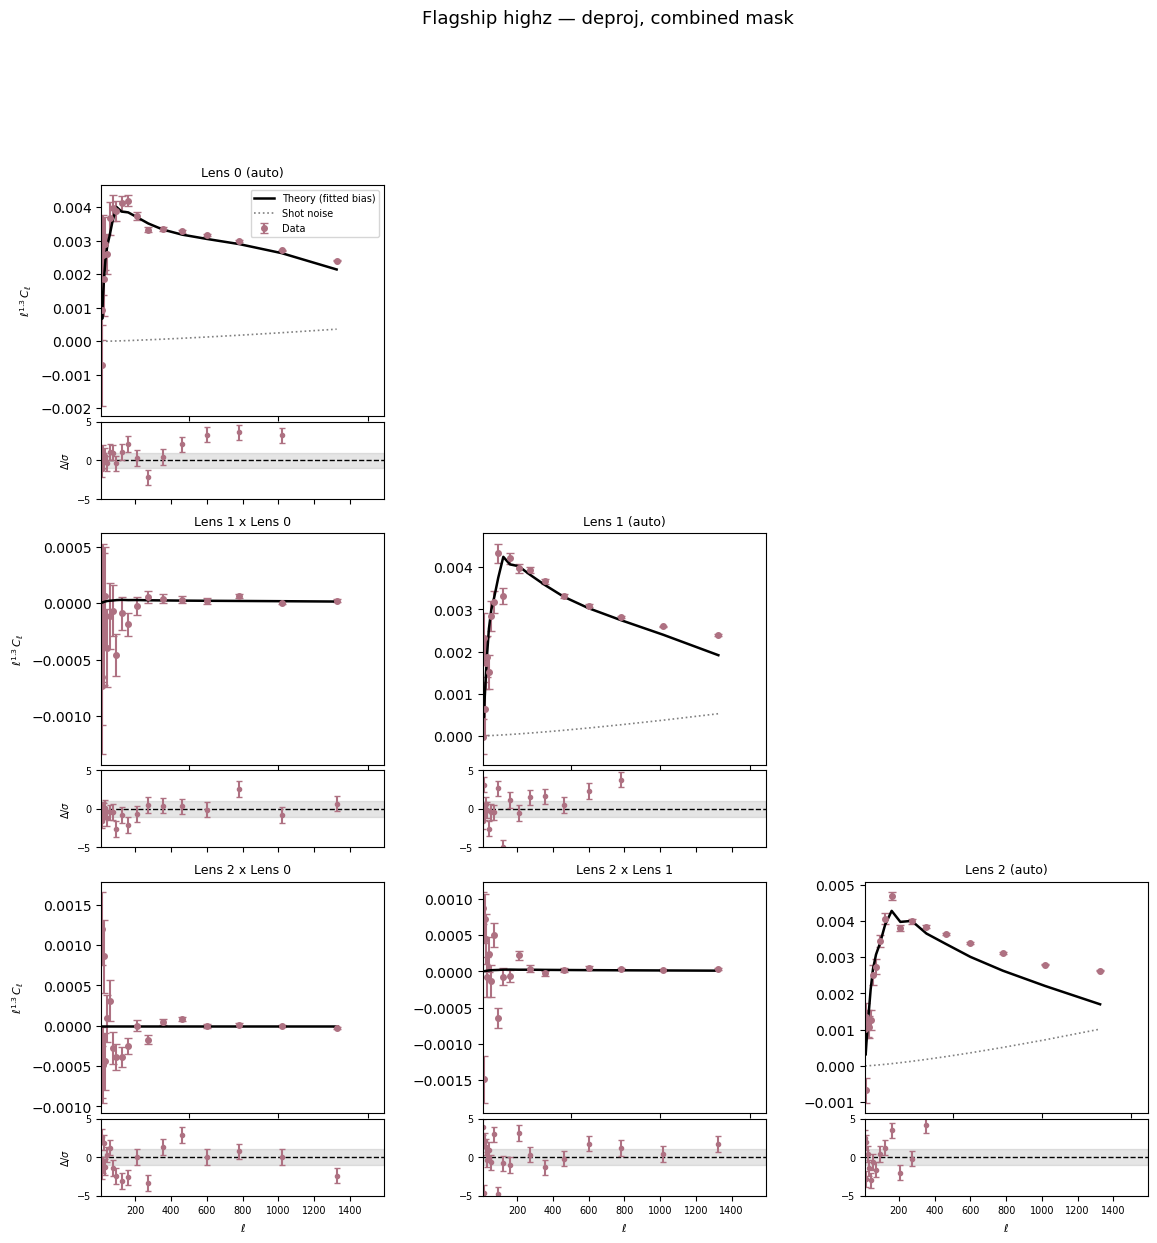

In [17]:
fig_f = plot_cls_vs_theory(
    cls_f, theory_f,
    title='Flagship highz — deproj, combined mask',
    shot_noise=shot_f,
    scale=SCALE,
)
plt.show()

### n(z) and density maps from catalogs

Same catalog cross-check as the Cardinal section: true-redshift distribution per bin from the photometry + tomography catalogs, and the reconstructed overdensity maps used in the $C_\ell$ measurement.

In [18]:
_z_mid, _nz, _counts, _zedges = read_nz_from_catalogs('Flagship')
nz_catalog['Flagship'] = {
    'z_mid': _z_mid, 'nz': _nz, 'counts': _counts, 'zedges': _zedges,
}

[Flagship] reading tomography ... 5.9s
[Flagship] reading redshift_true (~3 GB) ... 5.6s
[Flagship] total=479,593,273  lens-selected=33,727,270  (7.0%)
  bin 0 (0.4-0.6): 16,473,318
  bin 1 (0.6-0.8): 11,373,043
  bin 2 (0.8-1.0): 5,880,909


/tmp/ipykernel_2016790/2784462028.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(h, z_mid)


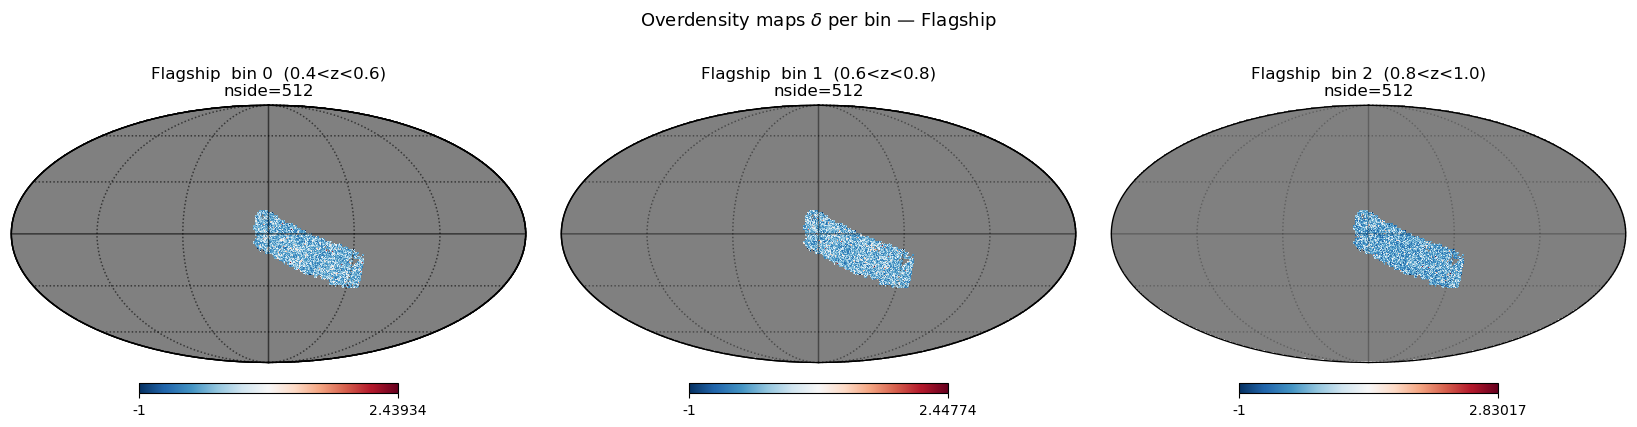

In [19]:
_nbin = 3
_label = 'Flagship'
_zedges = nz_catalog[_label]['zedges']

fig_maps_flagship = plt.figure(figsize=(5.5 * _nbin, 4.0))

for _b in range(_nbin):
    _dmap, _nside = read_density_map(_label, _b)
    _zlo = float(_zedges[_b])
    _zhi = float(_zedges[_b + 1])
    _sub = (1, _nbin, _b + 1)

    # clip colour range to +/-3 sigma for better contrast
    _vals = _dmap[_dmap != hp.UNSEEN]
    _vmax = float(np.percentile(np.abs(_vals), 99))

    hp.mollview(
        _dmap,
        fig=fig_maps_flagship.number,
        sub=_sub,
        title=f'{_label}  bin {_b}  ({_zlo:.1f}<z<{_zhi:.1f})\nnside={_nside}',
        cmap='RdBu_r',
        cbar=True,
        notext=True,
        margins=(0.01, 0.02, 0.01, 0.02),
    )
    hp.graticule(dpar=30, dmer=60, alpha=0.25, verbose=False)

fig_maps_flagship.suptitle(r'Overdensity maps $\delta$ per bin — Flagship', fontsize=13, y=1.05)
plt.show()

### Magnitudes

Same *ugrizy* magnitude read as the Cardinal section, reused later for the magnitude-distribution and color-color comparison plots.

In [20]:
_mags, _bin_mask, _weights, _zedges = read_magnitudes('Flagship')
mag_data['Flagship'] = {
    'mags': _mags, 'bin_mask': _bin_mask,
    'weights': _weights, 'zedges': _zedges,
}

[Flagship] reading tomography ... 5.7s
[Flagship] lens-selected: 33,727,270
  mag_u ... 7.2s
  mag_g ... 6.9s
  mag_r ... 7.6s
  mag_i ... 7.9s
  mag_z ... 6.8s
  mag_y ... 7.0s


### Mask and footprint statistics

Same mask plot and footprint cross-check as the Cardinal section, for Flagship.

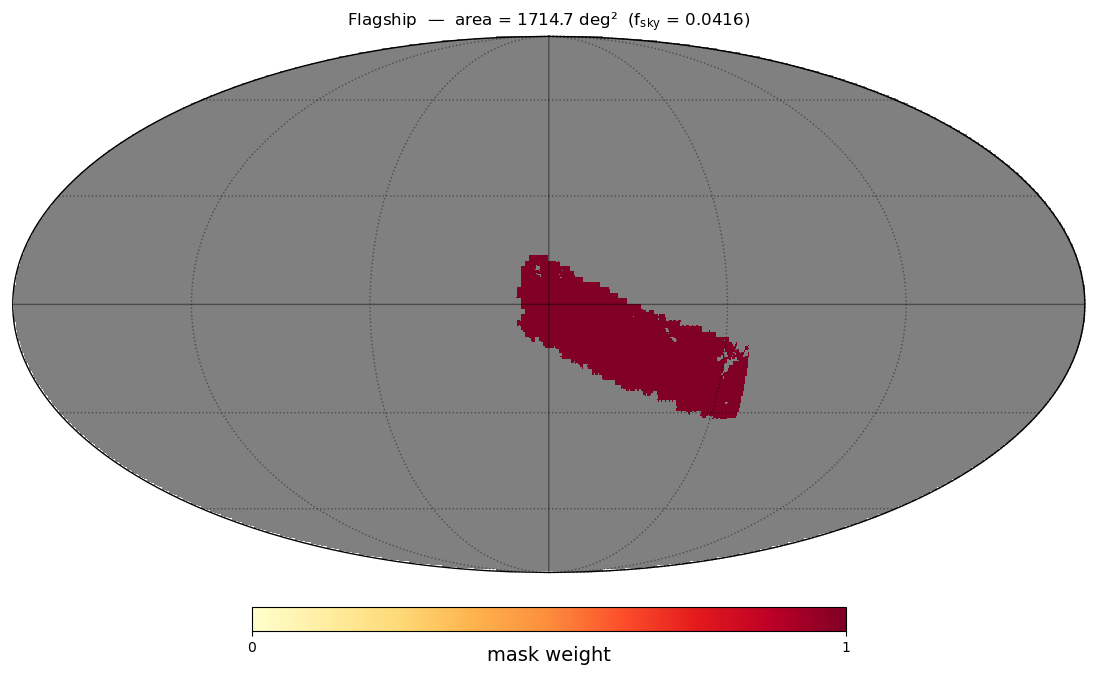

In [21]:
_mask_map, _nside, _attrs = read_txpipe_mask(runs['Flagship']['mask'])
_area  = float(_attrs.get('area',  _attrs.get('area_deg2',  0)))
_fsky  = float(_attrs.get('f_sky', _attrs.get('f_sky_computed', 0)))
_title = (f"Flagship  —  area = {_area:.1f} deg²  "
          f"(f$_{{\\rm sky}}$ = {_fsky:.4f})")

fig_mask_flagship = plt.figure(figsize=(12, 6.5))
hp.mollview(
    _mask_map,
    fig=fig_mask_flagship.number,
    sub=(1, 1, 1),
    title=_title,
    cmap='YlOrRd',
    min=0, max=1,
    cbar=True,
    notext=False,
    unit='mask weight',
)
hp.graticule(dpar=30, dmer=60, alpha=0.4, verbose=False)
plt.show()

In [22]:
_label = 'Flagship'
print(f"{'='*60}")
print(f"  {_label}  —  footprint statistics from tracer_metadata.hdf5")
print(f"{'='*60}")

with h5py.File(runs[_label]['meta']) as f:
    _tg         = f['tracers']
    _area_meta  = float(_tg.attrs['area'])
    _counts     = _tg['lens_counts'][:]
    _density    = _tg['lens_density'][:]
    _counts_2d  = int(_tg['lens_counts_2d'][0])
    _density_2d = float(_tg['lens_density_2d'][0])
    _zedges     = _tg.attrs['zbin_edges']

_, _, _mask_attrs = read_txpipe_mask(runs[_label]['mask'])
_area_mask = float(_mask_attrs.get('area',
                   _mask_attrs.get('area_deg2', 0)))
_fsky_mask = float(_mask_attrs.get('f_sky',
                   _mask_attrs.get('f_sky_computed', 0)))

_area_arcmin2 = _area_meta * 3600.0
_density_recomputed = _counts / _area_arcmin2

print(f"  Area (tracer_metadata) : {_area_meta:.4f} deg²")
print(f"  Area (mask file)       : {_area_mask:.4f} deg²", end="  ")
_area_match = abs(_area_meta - _area_mask) < 1e-6
print("✓ match" if _area_match else "✗ MISMATCH")

print(f"  f_sky (mask file)      : {_fsky_mask:.6f}")
print(f"  f_sky (recomputed)     : {_area_meta / (4*np.pi*(180/np.pi)**2):.6f}")

print()
print(f"  {'Bin':<8}  {'z range':>10}  "
      f"{'N_gal':>12}  {'n stored':>12}  {'n recomp':>12}  {'match':>6}")
print(f"  {'-'*8}  {'-'*10}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*6}")

all_ok = True
for _b, (_n, _d, _dr) in enumerate(
        zip(_counts, _density, _density_recomputed)):
    _zlo = float(_zedges[_b])
    _zhi = float(_zedges[_b+1])
    _rel_diff = abs(_d - _dr) / _dr if _dr > 0 else float('inf')
    _ok = _rel_diff < 1e-5
    all_ok = all_ok and _ok
    _flag = "✓" if _ok else "✗"
    print(f"  {'lens_'+str(_b):<8}  {f'{_zlo:.1f}–{_zhi:.1f}':>10}  "
          f"{int(_n):>12,}  {_d:>12.6f}  {_dr:>12.6f}  {_flag:>6}")

print()
print(f"  Total galaxies (sum of bins)  : {int(_counts.sum()):,}")
print(f"  Total galaxies (2d field)     : {_counts_2d:,}", end="  ")
print("✓ match" if int(_counts.sum()) == _counts_2d else "✗ MISMATCH")
print(f"  Total density  (stored)       : {_density_2d:.6f} gal/arcmin²")
print(f"  Total density  (recomputed)   : {_counts_2d / _area_arcmin2:.6f} gal/arcmin²")
print(f"  All per-bin density checks    : {'✓ pass' if all_ok else '✗ FAIL'}")
print()

  Flagship  —  footprint statistics from tracer_metadata.hdf5
  Area (tracer_metadata) : 1714.7163 deg²
  Area (mask file)       : 1714.7163 deg²  ✓ match
  f_sky (mask file)      : 0.041566
  f_sky (recomputed)     : 0.041566

  Bin          z range         N_gal      n stored      n recomp   match
  --------  ----------  ------------  ------------  ------------  ------
  lens_0       0.4–0.6    16,473,318      2.668617      2.668617       ✓
  lens_1       0.6–0.8    11,373,043      1.842391      1.842391       ✓
  lens_2       0.8–1.0     5,880,909      0.952686      0.952686       ✓

  Total galaxies (sum of bins)  : 33,727,270
  Total galaxies (2d field)     : 33,727,270  ✓ match
  Total density  (stored)       : 5.463695 gal/arcmin²
  Total density  (recomputed)   : 5.463695 gal/arcmin²
  All per-bin density checks    : ✓ pass



## Comparisons: Cardinal vs Flagship

Every plot below overlays both simulations directly, using the data and fits computed in the Cardinal and Flagship sections above.

## Fitted bias comparison

Side-by-side summary of the linear bias values fitted from each simulation.

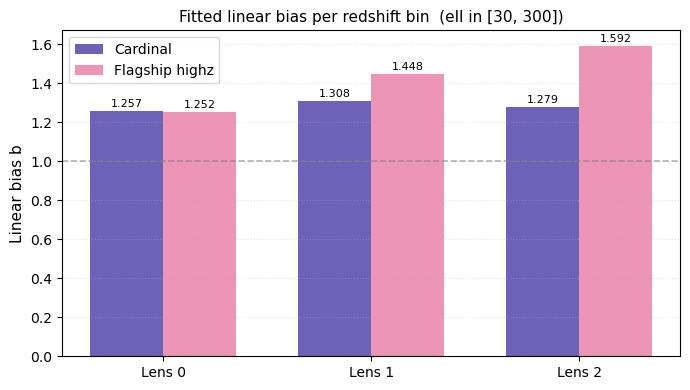

  Bin           Cardinal    Flagship   Ratio C/F
  lens_0          1.2569      1.2518      1.0041
  lens_1          1.3076      1.4475      0.9033
  lens_2          1.2790      1.5918      0.8035


In [23]:
bin_names = sorted(bias_c.keys(), key=parse_bin_index)
x     = np.arange(len(bin_names))
width = 0.35

fig_b, ax_b = plt.subplots(figsize=(7, 4))
bars_c = ax_b.bar(x - width / 2, [bias_c[b] for b in bin_names], width,
                  color=CARDINAL_COLOR, alpha=0.8, label='Cardinal')
bars_f = ax_b.bar(x + width / 2, [bias_f[b] for b in bin_names], width,
                  color=FLAGSHIP_COLOR, alpha=0.8, label='Flagship highz')

for bar in list(bars_c) + list(bars_f):
    ax_b.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8,
    )

ax_b.axhline(1.0, color='grey', lw=1.2, ls='--', alpha=0.6)
ax_b.set_xticks(x)
ax_b.set_xticklabels([bin_label(b) for b in bin_names], fontsize=10)
ax_b.set_ylabel('Linear bias b', fontsize=11)
ax_b.set_title(
    f'Fitted linear bias per redshift bin  (ell in [{BIAS_ELL_MIN}, {BIAS_ELL_MAX}])',
    fontsize=11,
)
ax_b.legend(fontsize=10)
ax_b.grid(True, axis='y', ls=':', alpha=0.35)
plt.tight_layout()
plt.show()

print(f'  {"Bin":10s}  {"Cardinal":>10s}  {"Flagship":>10s}  {"Ratio C/F":>10s}')
for b in bin_names:
    bc = bias_c[b]
    bf = bias_f[b]
    print(f'  {b:10s}  {bc:10.4f}  {bf:10.4f}  {bc/bf:10.4f}')

### Measured $C_\ell$ comparison

Overlays the raw measured $C_\ell$ (before theory subtraction) from both runs on the same axes.

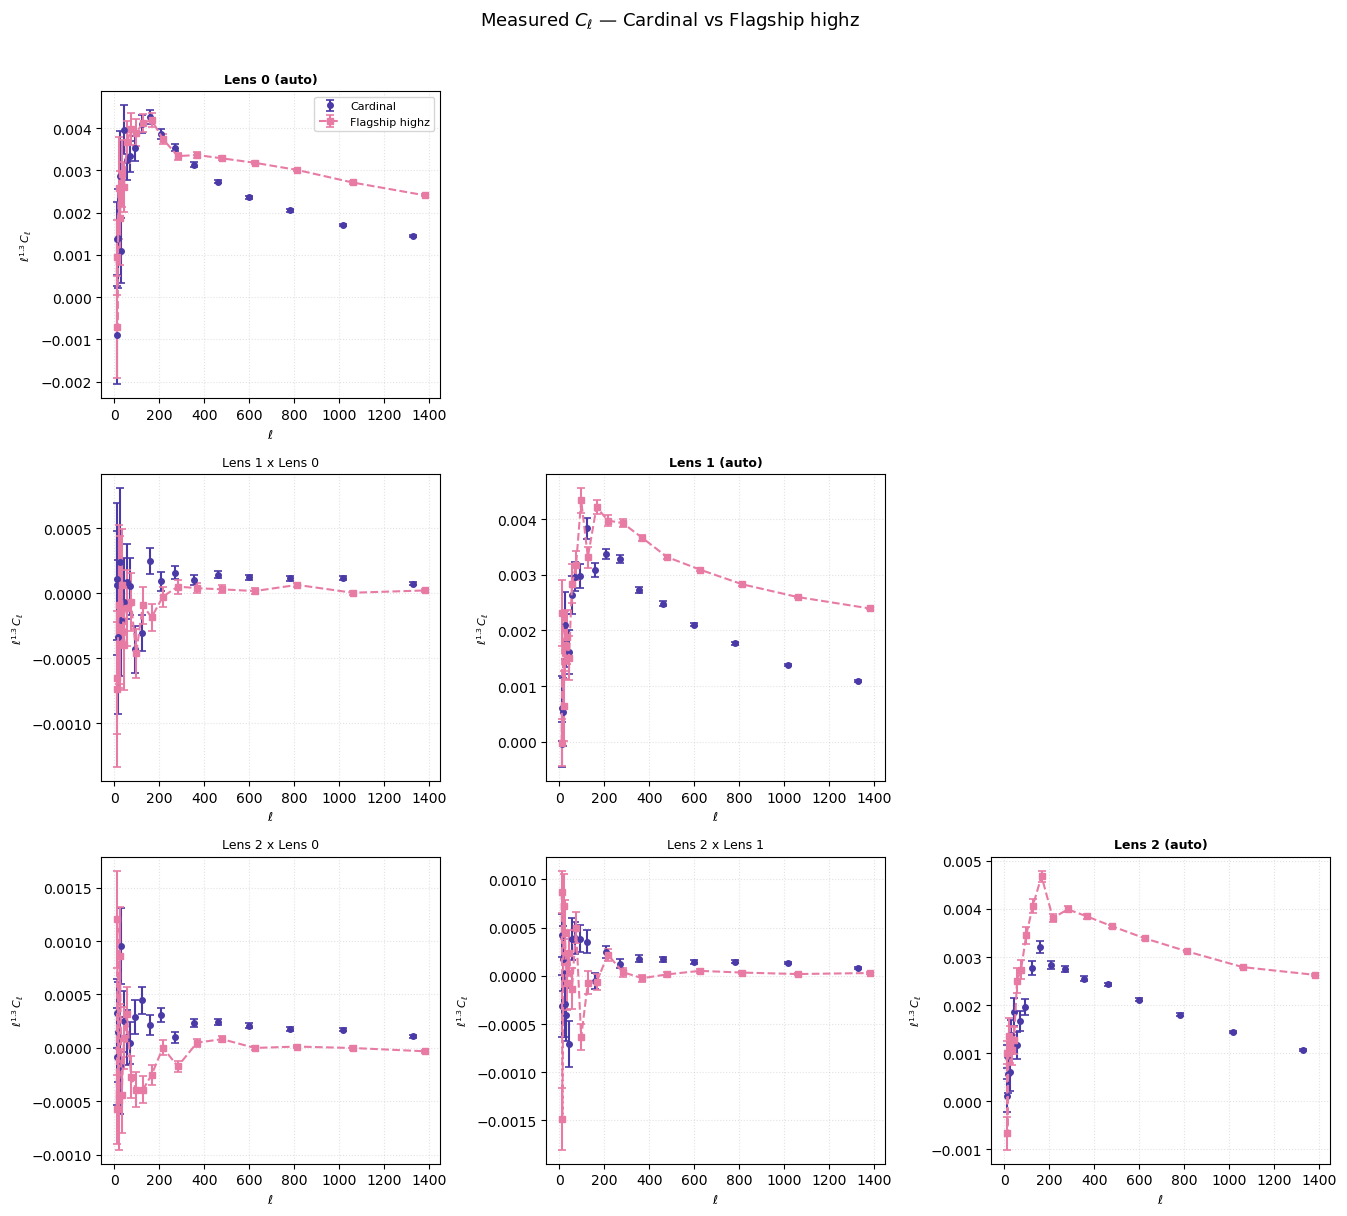

In [24]:
fig_overlay = plot_cls_overlay(
    cls_c, cls_f,
    label_a='Cardinal',
    label_b='Flagship highz',
    title='Measured $C_\\ell$ — Cardinal vs Flagship highz',
    scale=SCALE,
)
plt.show()

### n(z) comparison (sacc)

Overlays the n(z) stored in each run's sacc file, per tomographic bin.

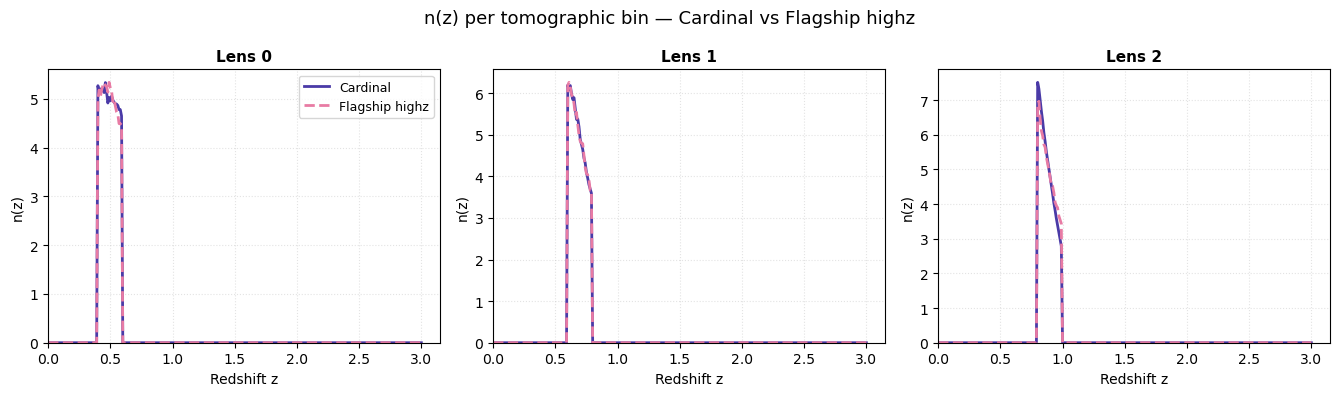

In [25]:
tracer_names_plot = sorted(s_c.tracers.keys(), key=parse_bin_index)
n_bins = len(tracer_names_plot)

fig_nz, axes_nz = plt.subplots(1, n_bins, figsize=(4.5 * n_bins, 4.0),
                               sharey=False)
if n_bins == 1:
    axes_nz = [axes_nz]

for i, name in enumerate(tracer_names_plot):
    ax = axes_nz[i]
    t_c = s_c.tracers[name]
    t_f = s_f.tracers[name]

    ax.plot(t_c.z, t_c.nz, '-',  lw=2.0, color=CARDINAL_COLOR, label='Cardinal')
    ax.plot(t_f.z, t_f.nz, '--', lw=2.0, color=FLAGSHIP_COLOR, label='Flagship highz')

    ax.set_xlabel('Redshift z', fontsize=10)
    ax.set_ylabel('n(z)', fontsize=10)
    ax.set_title(bin_label(name), fontsize=11, fontweight='bold')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, ls=':', alpha=0.35)
    if i == 0:
        ax.legend(fontsize=9, framealpha=0.8)

fig_nz.suptitle('n(z) per tomographic bin — Cardinal vs Flagship highz',
                fontsize=13)
plt.tight_layout()
plt.show()

### n(z) comparison (catalogs)

Overlays the true-redshift distributions computed directly from the photometry/tomography catalogs (solid/dashed) with the sacc n(z) (dotted), per tomographic bin, for both runs.

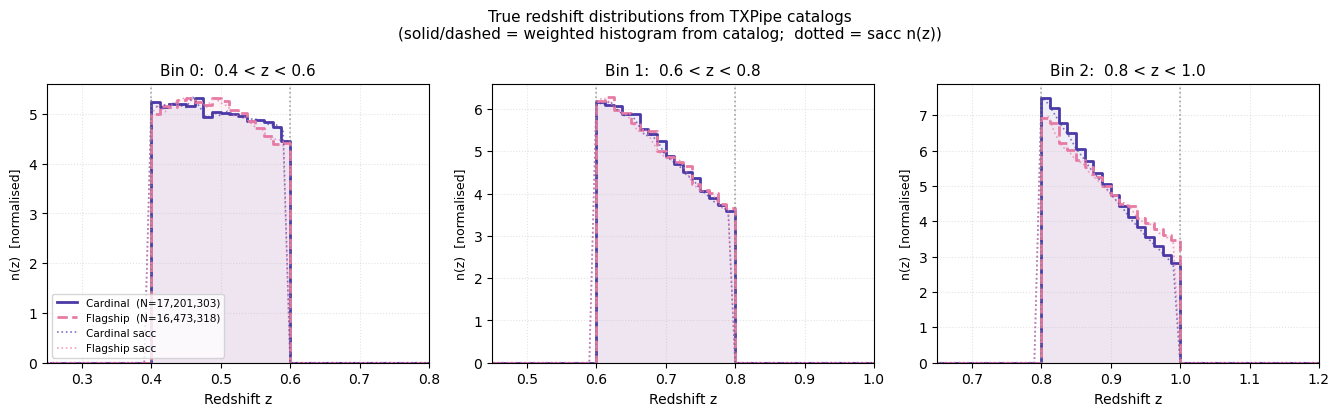

In [26]:
_nbin = len(nz_catalog['Cardinal']['nz'])
_zedges_c = nz_catalog['Cardinal']['zedges']

fig_nzcat, axes_nzcat = plt.subplots(
    1, _nbin, figsize=(4.5 * _nbin, 4.2), sharey=False
)

for _b in range(_nbin):
    ax = axes_nzcat[_b]
    for _label, _color, _ls in [('Cardinal', CARDINAL_COLOR, '-'), ('Flagship', FLAGSHIP_COLOR, '--')]:
        _d  = nz_catalog[_label]
        _n  = _d['counts'][_b]
        ax.step(_d['z_mid'], _d['nz'][_b], where='mid',
                color=_color, lw=2.0, ls=_ls, label=f'{_label}  (N={_n:,})')
        ax.fill_between(_d['z_mid'], _d['nz'][_b], step='mid',
                        color=_color, alpha=0.08)

    # Also overlay the sacc n(z) for comparison
    for _label, _s_obj, _color in [
        ('Cardinal sacc', s_c, CARDINAL_COLOR),
        ('Flagship sacc', s_f, FLAGSHIP_COLOR),
    ]:
        _tname = f'lens_{_b}'
        if _tname in _s_obj.tracers:
            _t = _s_obj.tracers[_tname]
            ax.plot(_t.z, _t.nz, color=_color, lw=1.2, ls=':', alpha=0.7,
                    label=f'{_label}')

    _zlo = float(_zedges_c[_b])
    _zhi = float(_zedges_c[_b + 1])
    ax.axvline(_zlo, color='grey', ls=':', lw=1.2, alpha=0.7)
    ax.axvline(_zhi, color='grey', ls=':', lw=1.2, alpha=0.7)
    ax.set_xlabel('Redshift z', fontsize=10)
    ax.set_ylabel('n(z)  [normalised]', fontsize=9)
    ax.set_title(f'Bin {_b}:  {_zlo:.1f} < z < {_zhi:.1f}', fontsize=11)
    ax.set_xlim(max(0, _zlo - 0.15), _zhi + 0.2)
    ax.set_ylim(bottom=0)
    ax.grid(True, ls=':', alpha=0.35)
    if _b == 0:
        ax.legend(fontsize=7.5, framealpha=0.8)

fig_nzcat.suptitle(
    'True redshift distributions from TXPipe catalogs\n'
    '(solid/dashed = weighted histogram from catalog;  dotted = sacc n(z))',
    fontsize=11,
)
plt.tight_layout()
plt.show()

### Magnitude distribution comparison

Overlays *ugrizy* magnitude histograms for lens-selected galaxies from both runs.

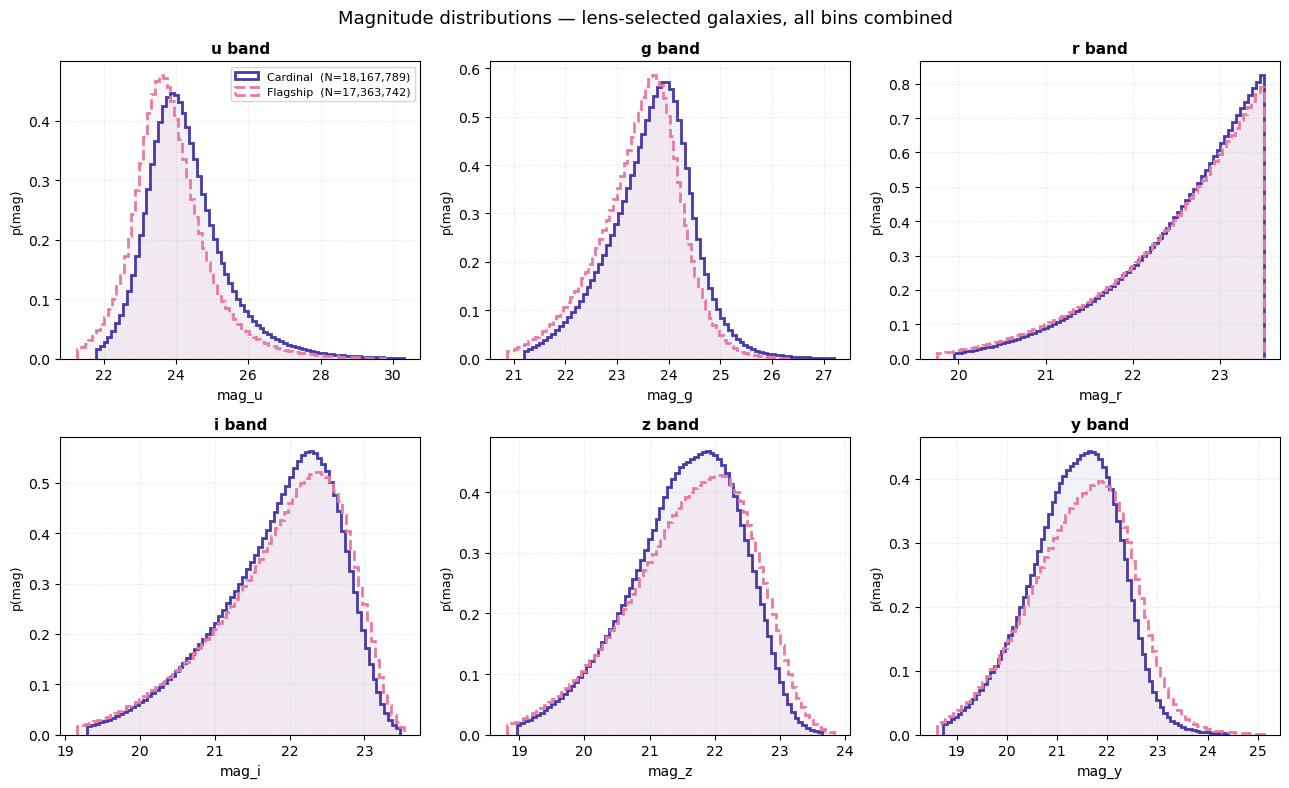

In [27]:
fig_mag, axes_mag = plt.subplots(2, 3, figsize=(13, 8))
axes_mag = axes_mag.flatten()

for _i, _band in enumerate(BANDS):
    ax = axes_mag[_i]
    for _label, _color, _ls in [('Cardinal', CARDINAL_COLOR, '-'), ('Flagship', FLAGSHIP_COLOR, '--')]:
        _m = mag_data[_label]['mags'][_band]
        # clip to sensible range; 99 is the TXPipe sentinel for no-detection
        _finite = _m[(_m > 14) & (_m < 32)]
        _lo  = float(np.percentile(_finite, 0.5))
        _hi  = float(np.percentile(_finite, 99.9))
        _bins = np.linspace(_lo, _hi, 80)
        ax.hist(_finite, bins=_bins, density=True,
                histtype='step', lw=2.0, color=_color, ls=_ls,
                label=f'{_label}  (N={len(_finite):,})')
        ax.fill_between(0.5*(_bins[:-1]+_bins[1:]),
                        np.histogram(_finite, bins=_bins, density=True)[0],
                        step='mid', color=_color, alpha=0.07)

    ax.set_xlabel(f'mag_{_band}', fontsize=10)
    ax.set_ylabel('p(mag)', fontsize=9)
    ax.set_title(f'{_band} band', fontsize=11, fontweight='bold')
    ax.grid(True, ls=':', alpha=0.35)
    if _i == 0:
        ax.legend(fontsize=8, framealpha=0.8)

fig_mag.suptitle(
    'Magnitude distributions — lens-selected galaxies, all bins combined',
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Color-color comparison

Overlays color-color density contours (30%, 68%, 95% enclosed) for four adjacent-band color pairs, both runs.

/tmp/ipykernel_2016790/3393565514.py:25: RuntimeWarning: invalid value encountered in subtract
  _cx = _m[b1] - _m[b2]
/tmp/ipykernel_2016790/3393565514.py:26: RuntimeWarning: invalid value encountered in subtract
  _cy = _m[b3] - _m[b4]


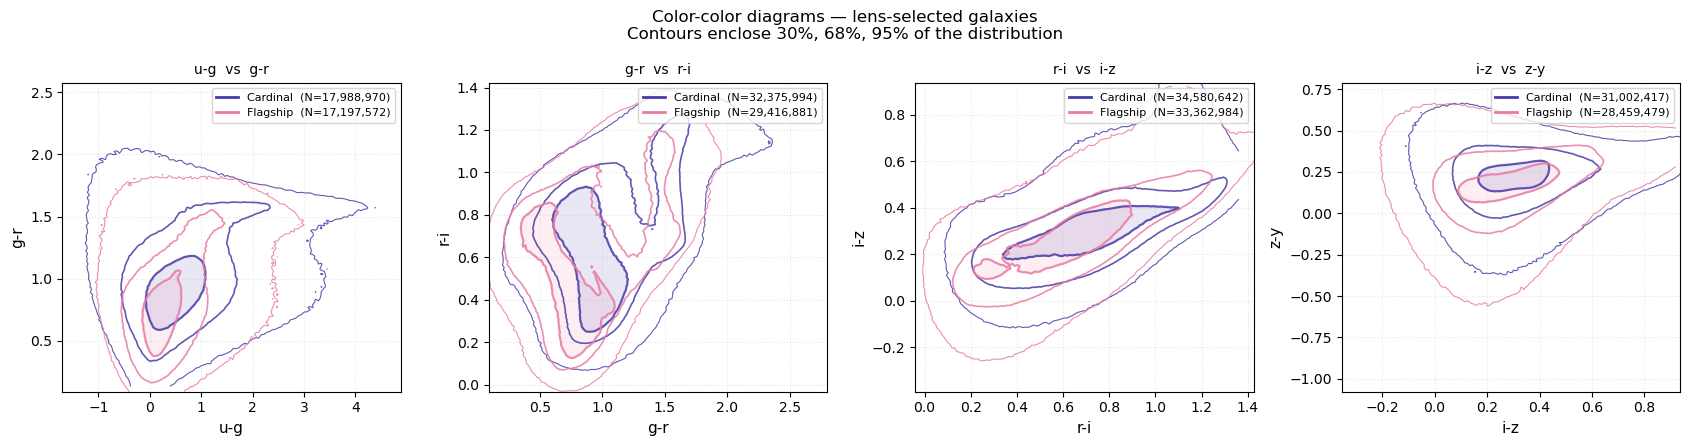

In [28]:
def _make_contour_levels(H, fracs=(0.95, 0.68, 0.30)):
    """Histogram levels enclosing `fracs` of the total probability mass."""
    Hf = np.sort(H.flatten())[::-1]
    cf = np.cumsum(Hf) / Hf.sum()
    return [float(Hf[min(np.searchsorted(cf, p), len(Hf)-1)]) for p in fracs]


_COLOR_PAIRS = [
    ('u', 'g', 'g', 'r'),   # u-g  vs  g-r
    ('g', 'r', 'r', 'i'),   # g-r  vs  r-i
    ('r', 'i', 'i', 'z'),   # r-i  vs  i-z
    ('i', 'z', 'z', 'y'),   # i-z  vs  z-y
]

fig_cc, axes_cc = plt.subplots(1, 4, figsize=(17, 4.5))

_RUN_STYLE = [('Cardinal', CARDINAL_COLOR), ('Flagship', FLAGSHIP_COLOR)]

for _ax, (b1, b2, b3, b4) in zip(axes_cc, _COLOR_PAIRS):
    _xlabel = f'{b1}-{b2}'
    _ylabel = f'{b3}-{b4}'

    for _label, _clr in _RUN_STYLE:
        _m = mag_data[_label]['mags']
        _cx = _m[b1] - _m[b2]
        _cy = _m[b3] - _m[b4]

        # keep only photometrically valid galaxies
        _ok = (np.isfinite(_cx) & np.isfinite(_cy) &
               (_m[b1] < 32) & (_m[b2] < 32) &
               (_m[b3] < 32) & (_m[b4] < 32))
        _cx, _cy = _cx[_ok], _cy[_ok]

        _xlo, _xhi = float(np.percentile(_cx, 0.5)),  float(np.percentile(_cx, 99.5))
        _ylo, _yhi = float(np.percentile(_cy, 0.5)),  float(np.percentile(_cy, 99.5))

        _H, _xe, _ye = np.histogram2d(_cx, _cy, bins=120,
                                       range=[[_xlo, _xhi], [_ylo, _yhi]])
        _H = _H.T
        _xc = 0.5 * (_xe[:-1] + _xe[1:])
        _yc = 0.5 * (_ye[:-1] + _ye[1:])
        _lvls = _make_contour_levels(_H)

        _ax.contourf(_xc, _yc, _H, levels=[_lvls[-1], _H.max()],
                     colors=[_clr], alpha=0.12)
        _ax.contour(_xc, _yc, _H, levels=_lvls,
                    colors=[_clr], linewidths=[0.8, 1.2, 1.6], alpha=0.85)
        _ax.plot([], [], color=_clr, lw=2, label=f'{_label}  (N={_ok.sum():,})')

    _ax.set_xlabel(_xlabel, fontsize=11)
    _ax.set_ylabel(_ylabel, fontsize=11)
    _ax.set_title(f'{_xlabel}  vs  {_ylabel}', fontsize=10)
    _ax.grid(True, ls=':', alpha=0.3)
    _ax.legend(fontsize=8, framealpha=0.8)

fig_cc.suptitle(
    'Color-color diagrams — lens-selected galaxies\n'
    'Contours enclose 30%, 68%, 95% of the distribution',
    fontsize=12,
)
plt.tight_layout()
plt.show()